Saving Cancer_Data.csv to Cancer_Data (1).csv

📊 Performance Comparison:

                       Accuracy  Precision    Recall  F1-score   ROC-AUC
Unbalanced Data        0.970760        1.0  0.921875   0.95935  0.995692
Balanced Data (SMOTE)  0.982456        1.0  0.953125   0.97600  0.997810


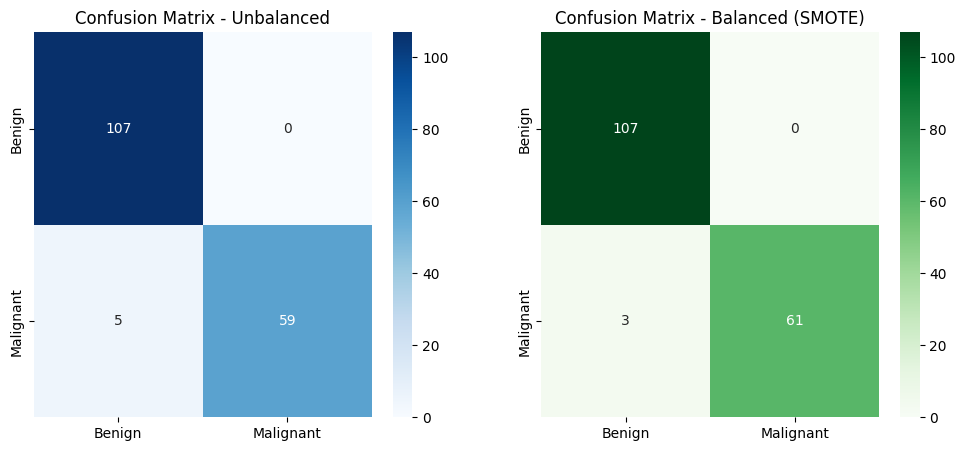

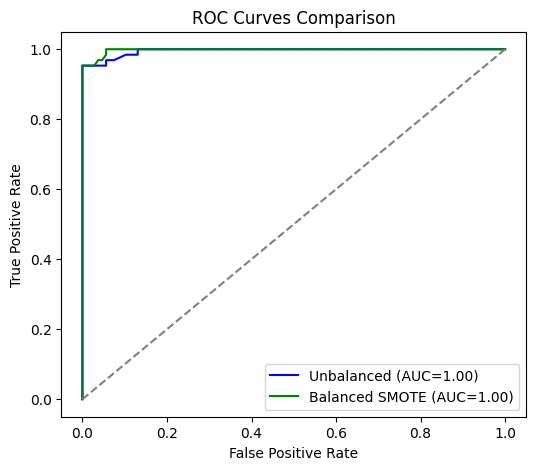

In [ ]:
# ================================
# Evaluate ML Algorithm on Balanced vs Unbalanced Dataset
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc

from imblearn.over_sampling import SMOTE

# 1. Upload dataset
uploaded = files.upload()
filename = list(uploaded.keys())[0]
data = pd.read_csv(filename)

# Drop the 'Unnamed: 32' column as it contains missing values
data = data.drop(columns=['Unnamed: 32'])

# 2. Preprocessing
X = data.drop(columns=['diagnosis'])
y = data['diagnosis'].map({'B':0, 'M':1})   # Benign=0, Malignant=1

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train on Unbalanced Data
clf_unbalanced = RandomForestClassifier(random_state=42)
clf_unbalanced.fit(X_train_scaled, y_train)
y_pred_unbalanced = clf_unbalanced.predict(X_test_scaled)
y_prob_unbalanced = clf_unbalanced.predict_proba(X_test_scaled)[:,1]

# 4. Balance with SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Train on Balanced Data
clf_balanced = RandomForestClassifier(random_state=42)
clf_balanced.fit(X_train_bal, y_train_bal)
y_pred_balanced = clf_balanced.predict(X_test_scaled)
y_prob_balanced = clf_balanced.predict_proba(X_test_scaled)[:,1]

# 5. Evaluation Metrics
def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results_unbalanced = get_metrics(y_test, y_pred_unbalanced, y_prob_unbalanced)
results_balanced = get_metrics(y_test, y_pred_balanced, y_prob_balanced)

# Convert to DataFrame for comparison
comparison = pd.DataFrame([results_unbalanced, results_balanced],
                          index=["Unbalanced Data", "Balanced Data (SMOTE)"])
print("\n📊 Performance Comparison:\n")
print(comparison)

# 6. Confusion Matrices
fig, ax = plt.subplots(1, 2, figsize=(12,5))

cm_unbalanced = confusion_matrix(y_test, y_pred_unbalanced)
sns.heatmap(cm_unbalanced, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"], yticklabels=["Benign","Malignant"], ax=ax[0])
ax[0].set_title("Confusion Matrix - Unbalanced")

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Benign","Malignant"], yticklabels=["Benign","Malignant"], ax=ax[1])
ax[1].set_title("Confusion Matrix - Balanced (SMOTE)")

plt.show()

# 7. ROC Curves
fpr_un, tpr_un, _ = roc_curve(y_test, y_prob_unbalanced)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_balanced)

plt.figure(figsize=(6,5))
plt.plot(fpr_un, tpr_un, color="blue", label=f"Unbalanced (AUC={results_unbalanced['ROC-AUC']:.2f})")
plt.plot(fpr_bal, tpr_bal, color="green", label=f"Balanced SMOTE (AUC={results_balanced['ROC-AUC']:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.show()